# Проект 3 модуля: предсказание возраста посетителей сайтов для компании «Йети»

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 26 июня 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/project_module_03_yeti
___

## Описание задачи

**IT‑компания «Йети»**, управляющая группой популярных интернет‑сервисов, получает значительную часть дохода от контекстной рекламы. Чтобы эффективно таргетировать объявления, компания использует демографический таргетинг — в том числе по возрасту. При этом паспортные данные пользователей не задействуются: возраст определяют на основе анализа поведения в цифровой среде.

**Задача** — разработать модель машинного обучения, которая по логам посещений сайтов будет автоматически определять возрастную категорию пользователя. В логах содержатся данные о том, какие категории сайтов посещал пользователь, с какой частотой и в какое время.

Корректное определение возрастной категории критически важно для эффективности рекламных кампаний. Например, яркую рекламу игрового гаджета нужно показывать зумерам, а рекламу семейного отпуска — молодым родителям. Если таргетинг будет неточным, бюджет на рекламу расходуется впустую, конверсия падает, а пользователи видят нерелевантные объявления. Кроме того, правильная сегментация позволяет избежать показа рекламы для взрослых несовершеннолетним. Результат работы модели ляжет в основу реализации маркетинговых стратегий и поможет существенно повысить релевантность рекламных показов.
___

## Выбор метрик

1. В качестве основной метрики используется `F1-мера`.  
Значение F1-меры лучшей модели должно быть **не меньше 0.75** и на кросс-валидации по обучающей выборке, и на тестовой выборке. В этом случае модель можно рекомендовать к внедрению.

2. Вспомогательные метрики качества: `precision` и `recall`.  
Модель нужно оценить одинаково по всем классам с использованием макро-усреднения.

___

## Описание данных

Данные представлены в нескольких CSV-файлах, полученных из разных источников.  
Необходимо их проанализировать, собрать в единую таблицу и построить модель с максимально полным набором признаков.  

#### 1. Таблица `ds_s13_users` содержит информацию о возрастной категории пользователя:  
`user_id` — уникальный идентификатор пользователя.  
`age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать.  
Содержит следующие категории:
- 0: младше 18;
- 1: 18-25 лет;
- 2: 26-40 лет;
- 3: 41-55 лет;
- 4: 56+ лет.


#### 2. Лог посещений сайтов `ds_s13_visits.csv` похож на данные сервиса веб-аналитики «Яндекс Метрика».  
Предназначен для сбора и анализа информации об активности пользователей разных сайтов. В целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.  
Признаки в датасете:  
`date` — дата посещения сайта.  
`daytime` — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.  
`session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.  
`user_id` — уникальный идентификатор пользователя.  
`website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.  

#### 3. Таблица `ads_activity`
Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом:  
`user_id` — уникальный идентификатор пользователя.  
`ads_activity` — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.  

#### 4. Таблица `surf_depth`
В таблице содержится два признака:  
`user_id` — уникальный идентификатор пользователя.  
`surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.  

#### 5. Таблица `primary_device`
Таблица содержит два признака:  
`user_id` — уникальный идентификатор пользователя.  
`primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

#### 6. Таблица `cloud_usage`
Использование облачных технологий:  
`user_id` — уникальный идентификатор пользователя;  
`cloud_usage` — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.
___

## Структура проекта

### 1. Подготовка среды и библиотек
___

## 1. Подготовка среды и библиотек

In [1]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка наличия jinja2 для отражения тепловой карты корреляций
import jinja2

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
from phik import phik_matrix

# Предобрабока данных
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest, RFE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

# Загружаем модели
# from sklearn.dummy import DummyClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC

# Модули для построения диаграммы калибровки
# from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
# from sklearn.frozen import FrozenEstimator

# Метрики
# from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve, brier_score_loss, log_loss

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
# import joblib
import os
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning) 

path = os.getcwd()
RANDOM_SEED = 555

In [8]:
# Подготовка функций и классов

# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df):

    df.columns = df.columns.str.replace(' ', '_').str.lower()

    dataset_cols_float = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
    dataset_cols_int = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

    for col in dataset_cols_float:
        df[col] = pd.to_numeric(df[col], downcast='float')

    for col in dataset_cols_int:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

# Подготавливаем функции визуализации данных и расчета метрик
# =========================
# bar chart

def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):

    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()

    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    fig, axes = plt.subplots(nrows=len(feature_list), ncols=1, figsize=(12, 2 * len(feature_list)))

    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i], vert=False)
        axes[i].set_title(f'Boxplot: {feature}')
        axes[i].tick_params(axis='x', labelrotation=0)
        axes[i].grid(axis='x', alpha=0.5) 

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# =========================
# phik heatmap
def phik_coolwarm_matrix(df: pd.DataFrame, target_var, interval_cols, matrix_view=True, figsize=(12, 12)):
    
    plt.figure(figsize=figsize)
    correlation_matrix = df.phik_matrix(interval_cols=interval_cols)
    if matrix_view:
        data_heatmap = correlation_matrix
    else:
        data_heatmap = correlation_matrix.loc[correlation_matrix.index != target_var][[target_var]].sort_values(by=target_var, ascending=False)
    sns.heatmap(data_heatmap,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
            )
    plt.yticks(rotation=0)
    plt.title('Тепловая карта коэффициента Phik \n')
    plt.show()



# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

# =========================
# Создаем класс для отбора признаков и последующей передачи в общий пайплайн
class RFEFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, estimator, n_features_to_select=25, step=1, verbose=0):
        self.estimator = estimator
        self.n_features_to_select = n_features_to_select
        self.step = step
        self.verbose = verbose
        self.rfe_selector = None
        self.selected_indices_ = None

    def fit(self, X, y=None):
        # Инициализируем RFE с тем же estimator
        self.rfe_selector = RFE(
            estimator=self.estimator,
            n_features_to_select=self.n_features_to_select,
            step=self.step,
            verbose=self.verbose
        )
        # Обучаем RFE на данных
        self.rfe_selector.fit(X, y)
        # Сохраняем индексы выбранных признаков
        self.selected_indices_ = self.rfe_selector.support_
        return self

    def transform(self, X):
        # Возвращаем только выбранные признаки
        if self.selected_indices_ is None:
            raise ValueError("Selector not fitted yet.")
        return X.iloc[:, self.selected_indices_] if hasattr(X, 'iloc') else X[:, self.selected_indices_]

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.input_features_
        return input_features[self.selected_indices_]

# =========================
# Класс преобразования числовых признаков log и sqrt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class LogSqrtTransformer(BaseEstimator, TransformerMixin):
    """
    Применяет log1p и sqrt к указанным колонкам, удаляет старые, добавляет новые с суффиксами.
    Поддерживает get_feature_names_out для интеграции в ColumnTransformer/Pipeline.
    """
    def __init__(self, log_cols=None, sqrt_cols=None):
        self.log_cols = log_cols or []
        self.sqrt_cols = sqrt_cols or []

    def fit(self, X, y=None):
        # Запоминаем имена входных признаков, если X — DataFrame
        if hasattr(X, "columns"):
            self.feature_names_in_ = list(X.columns)
        else:
            # Если на вход пришёл numpy-массив — генерируем заглушки
            n_features = X.shape[1]
            self.feature_names_in_ = [f"x{i}" for i in range(n_features)]
        return self

    def transform(self, X):
        X = X.copy()
        
        # Логарифмирование: log1p устойчивее к нулям
        for col in self.log_cols:
            new_col = f"{col}_log"
            X[new_col] = np.log1p(X[col])
        
        # Квадратный корень
        for col in self.sqrt_cols:
            new_col = f"{col}_sqrt"
            # Защита от отрицательных значений (если вдруг)
            X[new_col] = np.sqrt(np.maximum(X[col], 0))
        
        # Удаляем старые колонки (чтобы не было дублей)
        cols_to_drop = list(set(self.log_cols + self.sqrt_cols))
        X = X.drop(columns=cols_to_drop, errors='ignore')
        
        return X

    def get_feature_names_out(self, input_features=None):
        """
        Возвращает имена выходных признаков.
        
        Логика:
          - Для колонок из log_cols: имя = f"{col}_log"
          - Для колонок из sqrt_cols: имя = f"{col}_sqrt"
          - Для остальных колонок: имя остаётся без изменений
        """
        if input_features is None:
            input_features = self.feature_names_in_
        
        output_features = []
        
        for col in input_features:
            if col in self.log_cols:
                output_features.append(f"{col}_log")
            elif col in self.sqrt_cols:
                output_features.append(f"{col}_sqrt")
            else:
                # Колонки, которые не трансформировались, остаются как есть
                output_features.append(col)
        
        return np.array(output_features, dtype=object)




In [4]:
# Загрузка первичных данных

df_users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
df_visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
df_ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
df_surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
df_primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
df_cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

### 1.1 Датасет ds_users

In [9]:
df_users = optimize_dataframe(df_users)
df_users.head()

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


In [10]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int8  
dtypes: int8(1), object(1)
memory usage: 52.1+ KB


In [11]:
df_users.astype('str').describe()

,user_id,age_category
count,5913,5913
unique,5826,5
top,3fb4-b0158c2fc55a76a26265-7a5c374a,4
freq,2,1794


In [12]:
# Явные дубли присутствуют
df_users.duplicated().sum()

np.int64(87)

In [13]:
# Явные дубли устранены
# Первичный ключ user_id
df_users = df_users.drop_duplicates()
df_users.astype('str').describe()

,user_id,age_category
count,5826,5826
unique,5826,5
top,f545-8c95aefe8d3e5548a689-a5b2fd39,4
freq,1,1766


### 1.2 Датасет df_visits

In [15]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [14]:
df_visits = optimize_dataframe(df_visits)
df_visits.head()

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [16]:
# Явные дубли в наличии
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1065745,1065745,1065745,1065745,1065745
unique,14,4,1049995,5826,20
top,2025-11-13,день,c990d22e-a136-4660-91b2-6f7506c6ab81,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,76599,389052,2,853,70260


In [ ]:
# Требуется замена категорий daytime на латиницу
df_visits['daytime'].unique()

array(['evening', 'day', 'night', 'morning'], dtype=object)

In [ ]:
# Значения поля daytime станут новыми признаками  после One Hot Encoding, поэтому необходмо заметить русские назания на латиницу
df_visits['daytime'] = df_visits['daytime'].replace({'утро':'morning', 'день':'day', 'вечер':'evening','ночь':'night'})
df_visits['daytime'].unique()

array(['evening', 'day', 'night', 'morning'], dtype=object)

In [17]:
df_visits.duplicated().sum()

np.int64(15750)

In [18]:
# Явные дубли устранены
# Первичный ключ session_id
df_visits = df_visits.drop_duplicates()
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1049995,1049995,1049995,1049995,1049995
unique,14,4,1049995,5826,20
top,2025-11-13,день,066e4e02-8c1f-45eb-a50f-178659abe698,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,75491,383328,1,839,69129


### 1.3 Датасет df_ads_activity

In [20]:
df_ads_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [19]:
df_ads_activity = optimize_dataframe(df_ads_activity)
df_ads_activity.head()

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [21]:
df_ads_activity.describe()

,user_id,ads_activity
count,5826,5826
unique,5593,5
top,f45a-cfe100f3852bd9898527-a7a1b986,умеренно
freq,2,1897


In [ ]:
# Требуется кодирование категорий ads_activity на латиницу
df_ads_activity['ads_activity'].unique()

array(['очень часто', 'редко', 'очень редко', 'умеренно', 'часто'],
      dtype=object)

In [ ]:
# Значения поля ads_activity станут новыми признаками после One Hot Encoding, поэтому необходмо заметить русские назания на латиницу
df_ads_activity['ads_activity'] = df_ads_activity['ads_activity'].replace({'очень часто': 'ctr_4', 'часто': 'ctr_3', 'умеренно': 'ctr_2', 'редко': 'ctr_1', 'очень редко': 'ctr_0'})
df_ads_activity['ads_activity'].unique()

array(['ctr_4', 'ctr_1', 'ctr_0', 'ctr_2', 'ctr_3'], dtype=object)

In [22]:
# Явные дубли присутствют
df_ads_activity.duplicated().sum()

np.int64(233)

In [23]:
# Явные дубли устранены
# Первичный ключ user_id
df_ads_activity = df_ads_activity.drop_duplicates()
df_ads_activity.describe()

,user_id,ads_activity
count,5593,5593
unique,5593,5
top,e318-d8e69c86b543a5fb927c-c36fb6e6,умеренно
freq,1,1824


### 1.4 Датасет df_surf_depth

In [25]:
df_surf_depth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [24]:
df_surf_depth = optimize_dataframe(df_surf_depth)
df_surf_depth.head()

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [31]:
# Первичный ключ user_id
df_surf_depth.describe()

,user_id,surf_depth
count,5715,5715
unique,5715,3
top,f238-0c4c1e787cce311541b7-736925a0,средне
freq,1,2435


In [ ]:
# Требуется кодирование категорий surf_depth на латиницу
df_surf_depth['surf_depth'].unique()

array(['поверхностно', 'глубоко', 'средне'], dtype=object)

In [ ]:
# Значения поля surf_depth станут новыми признаками после One Hot Encoding, поэтому необходмо заметить русские назания на латиницу
df_surf_depth['surf_depth'] = df_surf_depth['surf_depth'].replace({'поверхностно': 'depth_0', 'средне': 'depth_1', 'глубоко': 'depth_2'})
df_surf_depth['surf_depth'].unique()

array(['depth_0', 'depth_2', 'depth_1'], dtype=object)

### 1.5 Датасет df_primary_device

In [36]:
df_primary_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [35]:
df_primary_device = optimize_dataframe(df_primary_device)
df_primary_device.head()

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


In [37]:
# Первичный ключ user_id
df_primary_device.describe()

,user_id,primary_device
count,5669,5669
unique,5669,4
top,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
freq,1,3083


In [38]:
# Требуется кодирование категорий surf_depth на латиницу
df_primary_device['primary_device'].unique()

array(['смартфон', 'ПК', 'ноутбук', 'планшет'], dtype=object)

In [39]:
# Значения поля surf_depth станут новыми признаками после One Hot Encoding, поэтому необходмо заметить русские назания на латиницу
df_primary_device['primary_device'] = df_primary_device['primary_device'].replace({'смартфон': 'smartphone', 'ПК': 'pc', 'ноутбук': 'laptop', 'планшет': 'tablet'})
df_primary_device['primary_device'].unique()

array(['smartphone', 'pc', 'laptop', 'tablet'], dtype=object)

### 1.6 Датасет df_cloud_usage

In [40]:
# Первичный ключ user_id
df_cloud_usage = optimize_dataframe(df_cloud_usage)
df_cloud_usage.head()

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


In [41]:
df_cloud_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.1+ KB


In [42]:
df_cloud_usage.describe()

,user_id,cloud_usage
count,5680,5680
unique,5680,2
top,a1e4-91c8a52eb855595e653f-298ce305,True
freq,1,2951


## Комментарии по итогам подготовки среды и библиотек

Загружены основные библиотеки, подготовлены функции для использования в ходе всего проекта, заданы константы и сделаны необходимые настройки предупреждений.  

Успешно загружены 6 датасетов: `df_users`, `df_visits`,`df_ads_activity`, `df_surf_depth`, `df_primary_device`, `df_cloud_usage`.  

Пропуски в датасетах отсутсвуют.

Для подготовки полного набора данных признак - целевая переменная необходимо определить первичные и внешние ключи отдельных датасетах, удостоверится в уникальности (устранить дубли) первичном ключе.

1) Датасет `df_users` - содержит данные со значениями целевой переменной **age_category**.  
Состав: 5915 строк с дублями. После устранения дублей получаем первичный ключ **user_id** - 5826 уникальных пользователей.  

2) `df_visits` - лог посещений пользователями ваб-сайтов. **1 065 745** строк, **15 750** явных дублей. Дубли удалены. Первичный уникальный ключ - **session_id** (1 049 995 уникальных записи). Также датасет содержит признаки date (14 уникальных записей), daytime (4 уникальных записи), **user_id** - внешний ключ 5826 записей, website_category (20 уникальных значений).

3) `df_ads_activity`. 5826 записей. Содержал явные дубли. После устранения дублей получен первичный ключ **user_id** (5593 значения) и признак ads_activity с 5 уникальными значениями.

4) Датасет `df_surf_depth`. Не содержит дублей. 5715 записей. Первичный ключ **user_id**, признак surf_depth - 3 уникальных значения.

5) `df_primary_device`: 5569 строк без явных дублей. Первичный ключ **user_id**, признак primary_device имеет 4 уникальных значения.

6) Источник `df_cloud_usage` состоит из 5580 строк. Первичный ключ **user_id**, бинарный признак cloud_usage имеет 2 значения True/False.

Итого: объединение всех 6-ти датасетов будем проводить по ключу **user_id**. Число уникальных записей по первичному ключу совпадает не во всех датасетах, значит будут пропуски при соединении по left join. Нужно определиться с методами их заполнения. Данные логов `df_visits` необходимо сгруппировать и привести к виду, где **user_id** также будет первичным ключом.

____

## 2. Исследовательский анализ данных

### 2.1 Первичный анализ отдельных загруженных датасетов

#### 2.1.1 Датасет с целевой переменной `df_users`

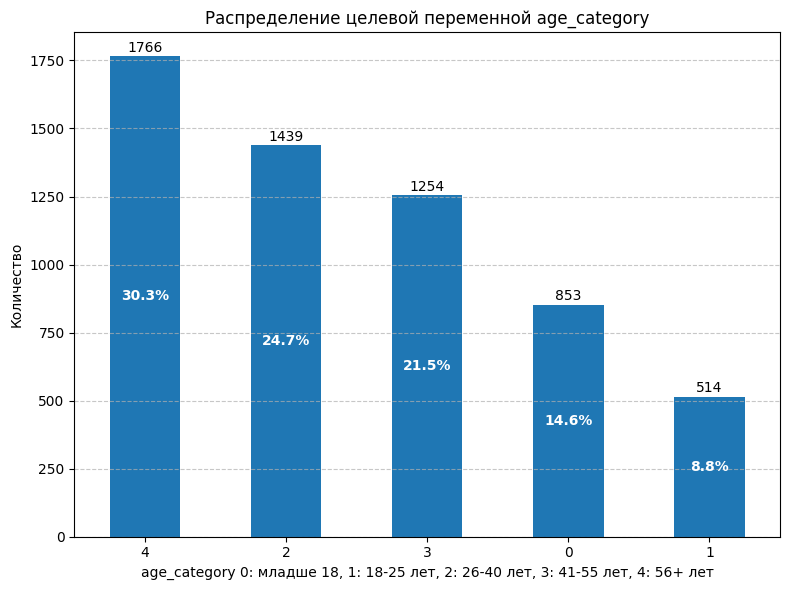

In [43]:
plot_bar_chart(data=df_users['age_category'], figsize=(8, 6), xlabel='age_category 0: младше 18, 1: 18-25 лет, 2: 26-40 лет, 3: 41-55 лет, 4: 56+ лет', ylabel='Количество', title='Распределение целевой переменной age_category')

#### 2.1.2 Датасет `df_ads_activity`

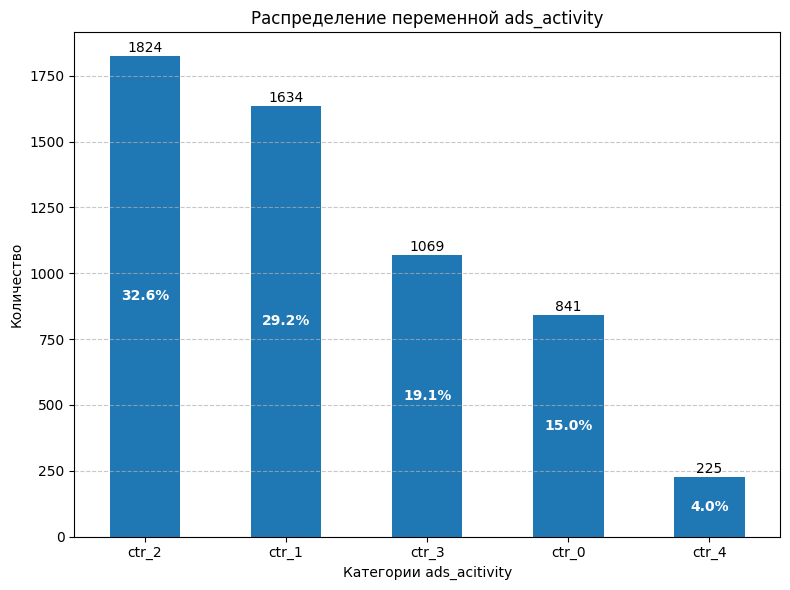

In [44]:
plot_bar_chart(data=df_ads_activity['ads_activity'], figsize=(8, 6), xlabel='Категории ads_acitivity', ylabel='Количество', title='Распределение переменной ads_activity')

#### 2.1.3 Датасет `df_surf_depth`

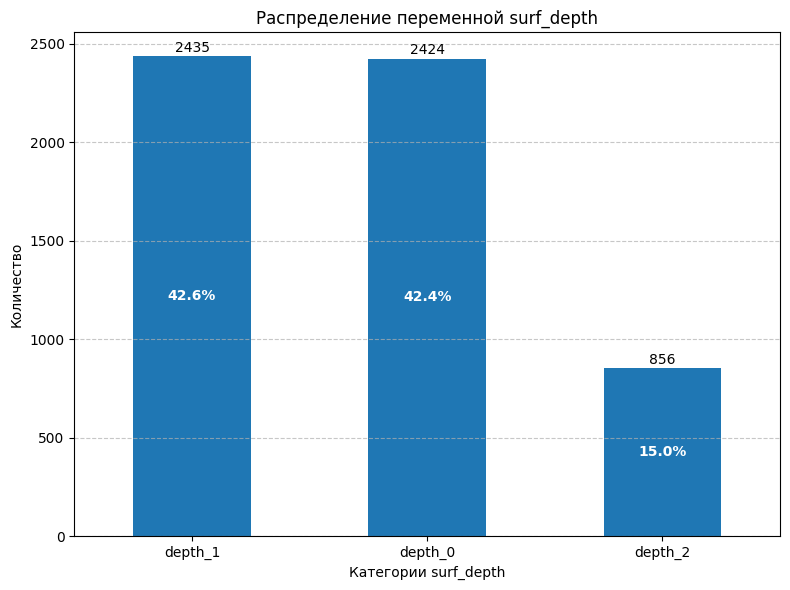

In [45]:
plot_bar_chart(data=df_surf_depth['surf_depth'], figsize=(8, 6), xlabel='Категории surf_depth', ylabel='Количество', title='Распределение переменной surf_depth')

#### 2.1.4 Датасет `df_primary_device`

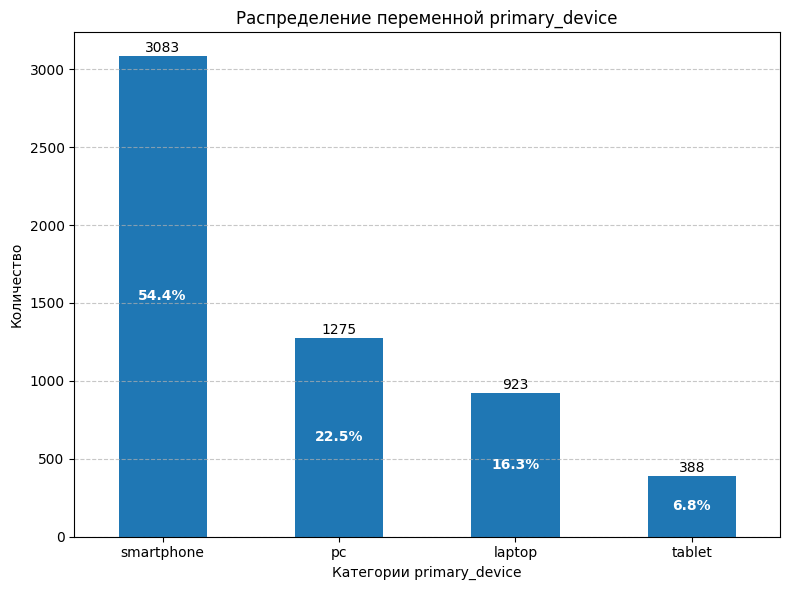

In [46]:
plot_bar_chart(data=df_primary_device['primary_device'], figsize=(8, 6), xlabel='Категории primary_device', ylabel='Количество', title='Распределение переменной primary_device')

#### 2.1.5 Датасет `df_cloud_usage`

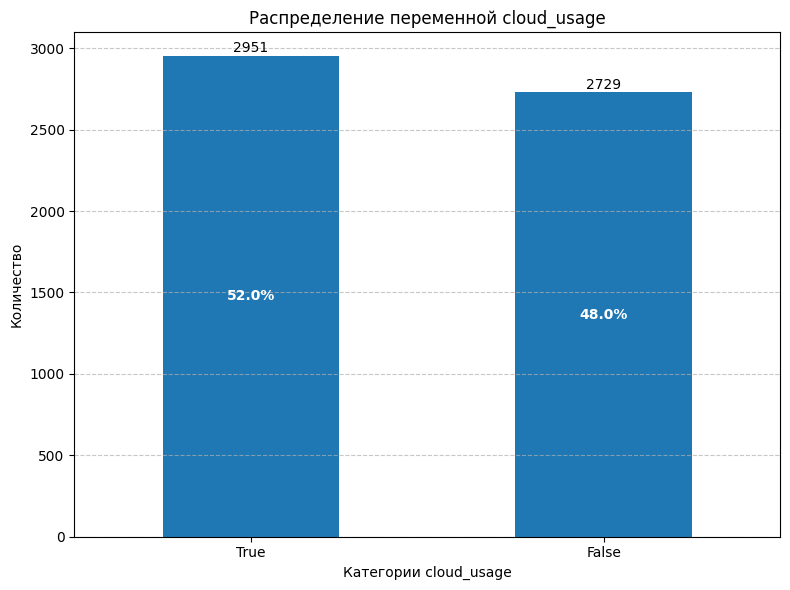

In [47]:
plot_bar_chart(data=df_cloud_usage['cloud_usage'], figsize=(8, 6), xlabel='Категории cloud_usage', ylabel='Количество', title='Распределение переменной cloud_usage')

#### 2.1.6 Датасет `df_visits`

In [48]:
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1049995,1049995,1049995,1049995,1049995
unique,14,4,1049995,5826,20
top,2025-11-13,day,066e4e02-8c1f-45eb-a50f-178659abe698,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,75491,383328,1,839,69129


In [49]:
# Проверяем уникальные значения в столбцах и ищем неявные пропуски
# В анализ добавляем признаки, исключая первичный session_id в внешний ключ user_id 
visits_features = ['date', 'daytime', 'website_category']

for column in visits_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_visits[column].sort_values().unique())
    print('Число уникальных значений:', df_visits[column].sort_values().nunique())
    print()

Уникальные значения в столбце date:
['2025-11-01' '2025-11-02' '2025-11-03' '2025-11-04' '2025-11-05'
 '2025-11-06' '2025-11-07' '2025-11-08' '2025-11-09' '2025-11-10'
 '2025-11-11' '2025-11-12' '2025-11-13' '2025-11-14']
Число уникальных значений: 14

Уникальные значения в столбце daytime:
['day' 'evening' 'morning' 'night']
Число уникальных значений: 4

Уникальные значения в столбце website_category:
['Category 01' 'Category 02' 'Category 03' 'Category 04' 'Category 05'
 'Category 06' 'Category 07' 'Category 08' 'Category 09' 'Category 10'
 'Category 11' 'Category 12' 'Category 13' 'Category 14' 'Category 15'
 'Category 16' 'Category 17' 'Category 18' 'Category 19' 'Category 20']
Число уникальных значений: 20



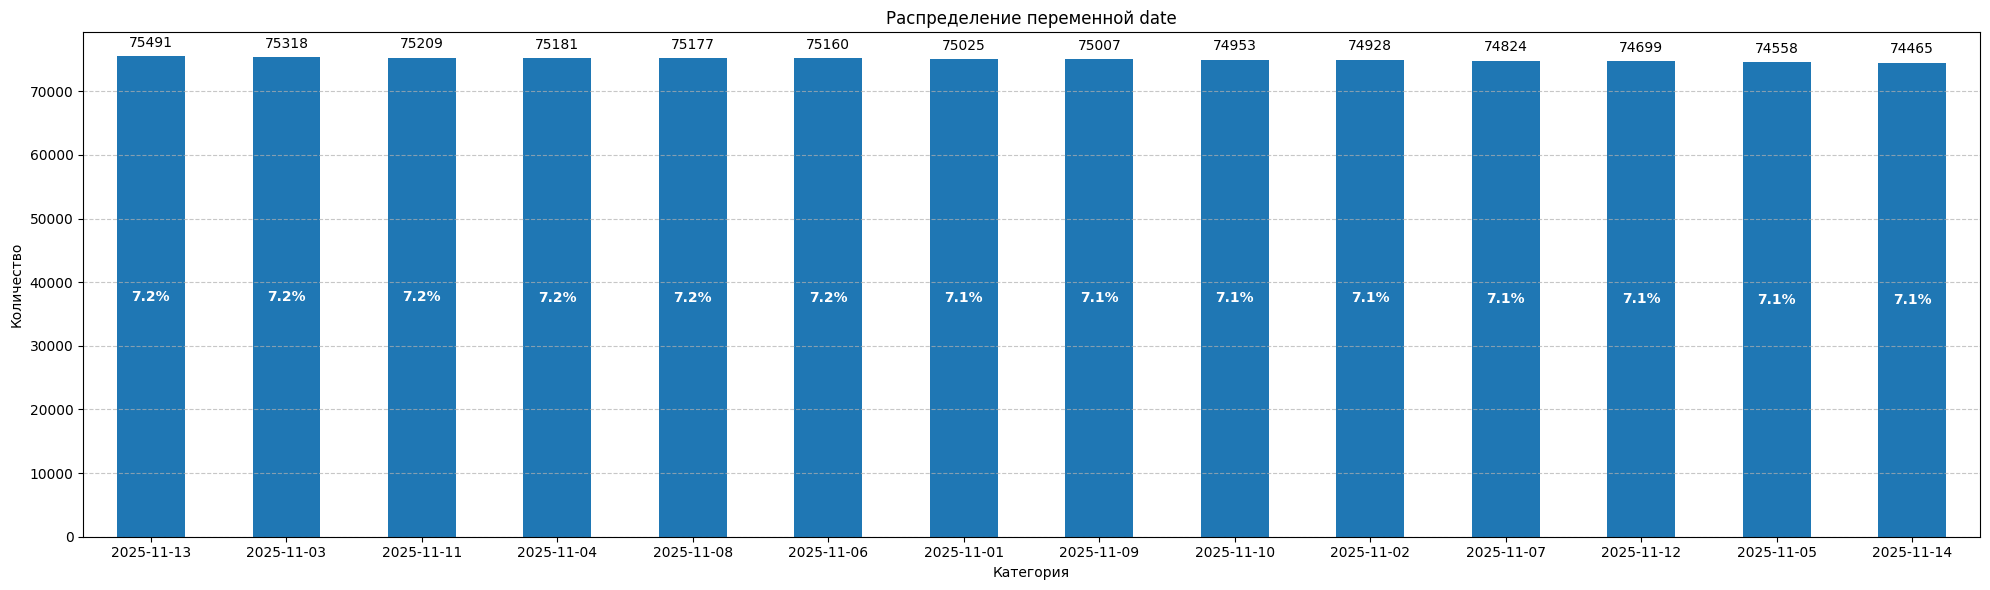

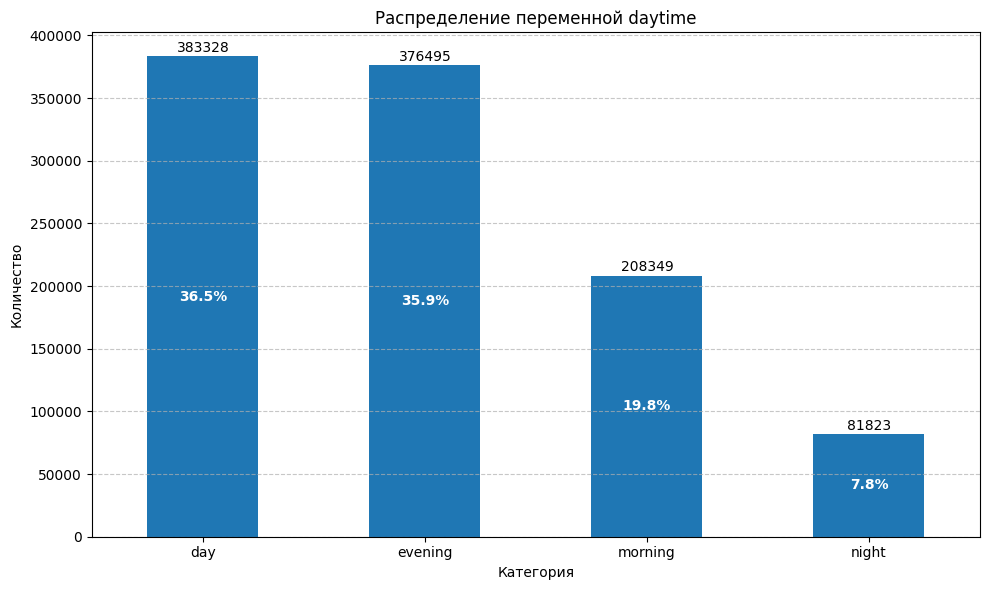

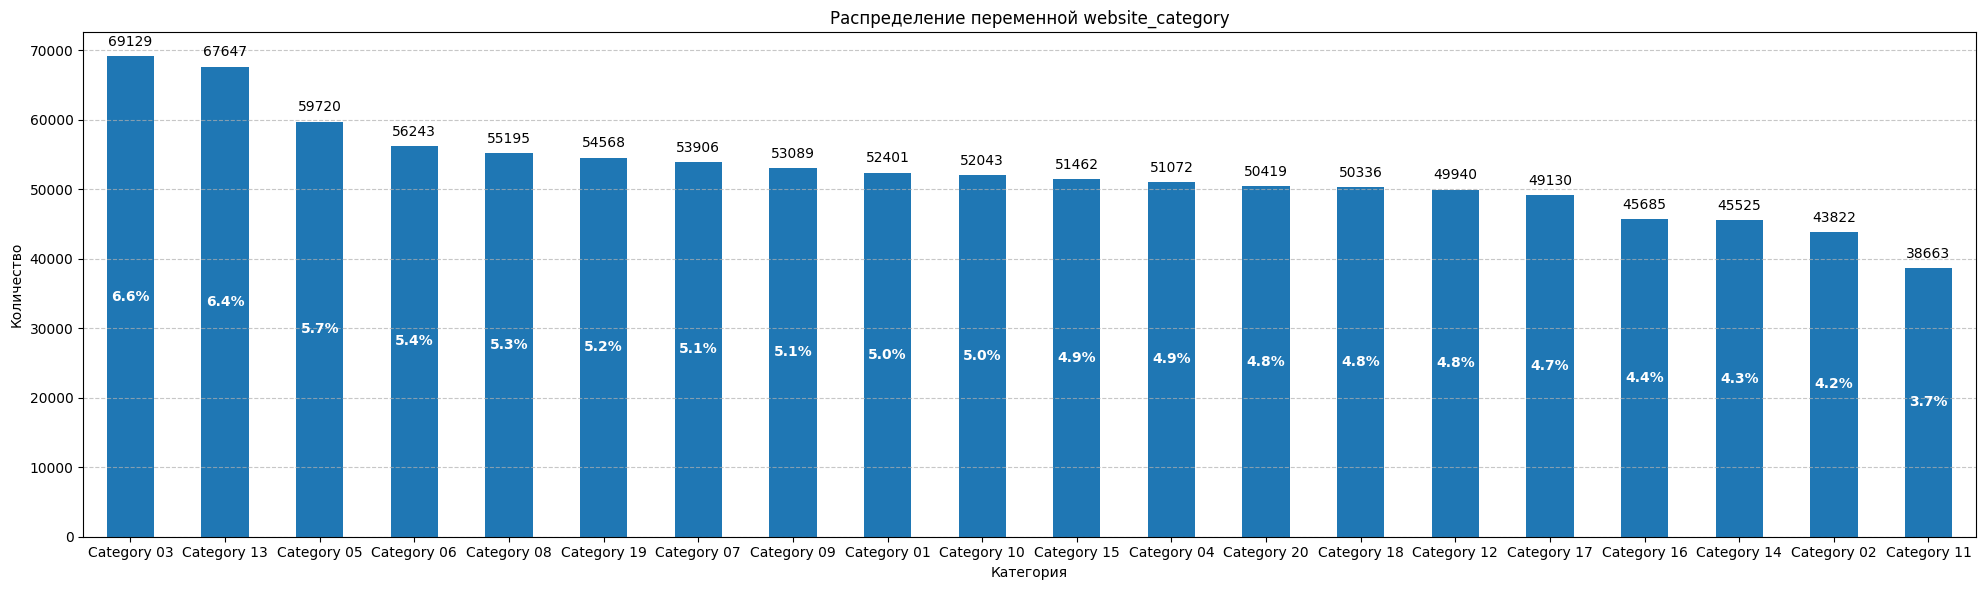

In [50]:
for feature in visits_features:
    if feature == 'daytime':
        top_n = 4
        fs = (10, 6)
    else:
        top_n = 30
        fs = (20, 6)
    plot_bar_chart(data=df_visits[feature], figsize=fs, title=f'Распределение переменной {feature}', top_n=top_n)

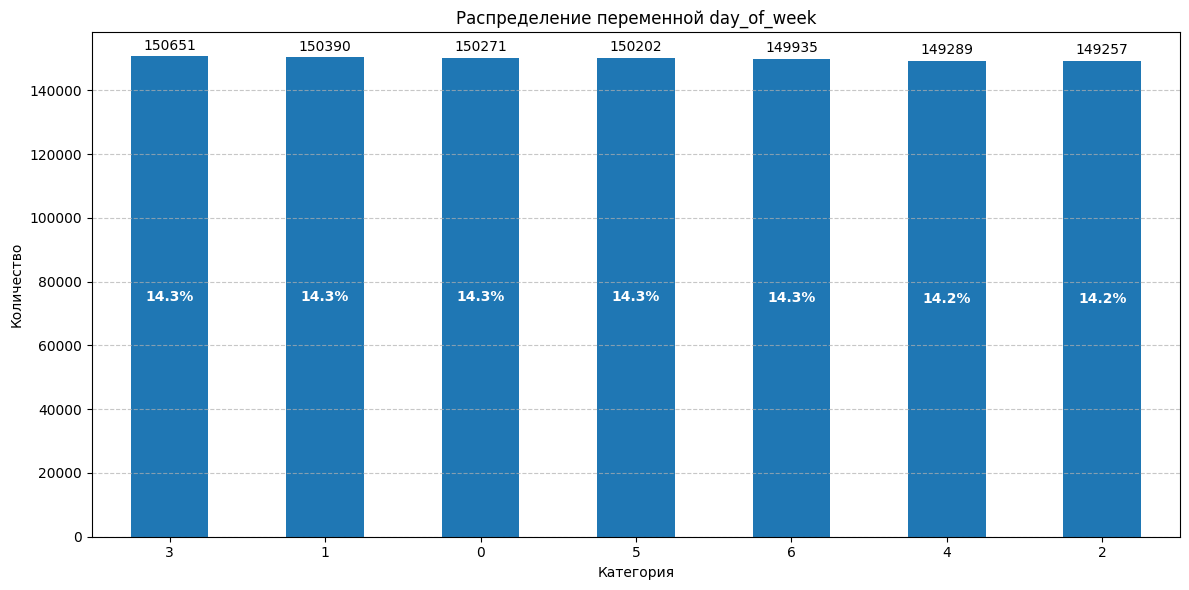

In [51]:
plot_bar_chart(data=pd.to_datetime(df_visits['date']).dt.day_of_week, figsize=(12,6), title=f'Распределение переменной day_of_week', top_n=10) 

### Комментарий
___

### 2.2 Создание единого датасета "объект-признак"

In [52]:
def build_df_users_features(
        df_users: pd.DataFrame,
        df_visits: pd.DataFrame,
        df_ads_activity: pd.DataFrame,
        df_surf_depth: pd.DataFrame,
        df_primary_device: pd.DataFrame,
        df_cloud_usage: pd.DataFrame
    ) -> pd.DataFrame:
    """
    Строит агрегированный датасет с первичным ключом user_id на основе 6 исходных датасетов:
    df_users, df_visits, df_ads_activity, df_surf_depth, df_primary_device, df_cloud_usage
    
    df_visits трансформируется с первичным ключом user_id 
    в DataFrame с новыми признаками:
      - базовые: total_sessions, avg_sessions_per_day
      - доли по времени суток: share_night, share_morning, share_day, share_evening
      - доли по категориям сайтов: share_cat_Category_X (20 шт.)
      - разнообразие: entropy_category, entropy_daytime
      - флаги: is_high_activity_user
      - отношение: ratio_evening_to_morning
    """
    df = df_visits.copy()

    # Преобразуем date в datetime
    df['date_dt'] = pd.to_datetime(df['date'])

    # -------------------------
    # Базовые агрегаты по user_id
    # -------------------------
    base_agg = (
        df.groupby('user_id')
          .agg(
              total_sessions=('session_id', 'count'),
              days_active=('date_dt', 'nunique')  # считаем уникальные дни автоматически
          )
          .reset_index()
    )
    
    # avg_sessions_per_day: избегаем деления на 0, если вдруг days_active == 0
    base_agg['avg_sessions_per_day'] = (
        base_agg['total_sessions'] / base_agg['days_active'].replace(0, 1)
    )

    # Порог для is_high_activity_user (75 перцентиль total_sessions)
    threshold_75 = base_agg['total_sessions'].quantile(0.75)
    base_agg['is_high_activity_user'] = (base_agg['total_sessions'] > threshold_75).astype(int)

    # Убираем days_active из финального набора — он нужен только для расчёта avg, но сам по себе не несёт информации
    base_agg = base_agg.drop(columns=['days_active'])

    # -------------------------
    # Доли по времени суток (daytime)
    # -------------------------
    time_shares = (
        pd.crosstab(df['user_id'], df['daytime'], values=df['session_id'], aggfunc='count')
        .fillna(0)
    )
    time_shares = time_shares.div(time_shares.sum(axis=1), axis=0)  # нормализация по строкам
    time_shares = time_shares.add_prefix('share_')

    # ratio_evening_to_morning: отношение долей (если morning=0, избегаем деления на 0)
    ratio_evening_morning = (
        time_shares['share_evening'] / time_shares['share_morning'].replace(0, np.nan)
    ).fillna(0).rename('ratio_evening_to_morning')

    # -------------------------
    # Доли по категориям сайтов (website_category)
    # -------------------------
    cat_shares = (
        pd.crosstab(df['user_id'], df['website_category'], values=df['session_id'], aggfunc='count')
        .fillna(0)
    )
    cat_shares = cat_shares.div(cat_shares.sum(axis=1), axis=0)
    cat_shares = cat_shares.add_prefix('share_cat_')
    cat_shares.columns = cat_shares.columns.str.replace(' ', '_').str.lower()

    # -------------------------
    # Энтропия (разнообразие)
    # -------------------------
    def entropy(p: pd.Series) -> float:
        p = p[p > 0]
        if len(p) == 0:
            return 0.0
        return -np.sum(p * np.log2(p))

    entropy_category = cat_shares.apply(entropy, axis=1).rename('entropy_category')
    entropy_daytime = time_shares.apply(entropy, axis=1).rename('entropy_daytime')

    # -------------------------
    # Сборка итогового DataFrame
    # -------------------------
    result_visits = base_agg.merge(time_shares, on='user_id', how='left')
    result_visits = result_visits.merge(cat_shares, on='user_id', how='left')
    result_visits = result_visits.merge(entropy_category, left_on='user_id', right_index=True, how='left')
    result_visits = result_visits.merge(entropy_daytime, left_on='user_id', right_index=True, how='left')
    result_visits = result_visits.merge(ratio_evening_morning, left_on='user_id', right_index=True, how='left')
    # Заполним NaN нулями (на случай пользователей с очень редкими категориями/временными окнами)
    result_visits = result_visits.fillna(0)


    result_final = df_users.merge(result_visits, left_on='user_id', right_on='user_id', how='left')
    result_final = result_final.merge(df_ads_activity, left_on='user_id', right_on='user_id', how='left')
    result_final = result_final.merge(df_surf_depth, left_on='user_id', right_on='user_id', how='left')
    result_final = result_final.merge(df_primary_device, left_on='user_id', right_on='user_id', how='left')
    result_final = result_final.merge(df_cloud_usage, left_on='user_id', right_on='user_id',  how='left')

    return result_final


In [53]:
df_users_logs = optimize_dataframe(build_df_users_features(df_users, df_visits, df_ads_activity, df_surf_depth, df_primary_device, df_cloud_usage))
df_users_logs.head()

,user_id,age_category,total_sessions,avg_sessions_per_day,is_high_activity_user,share_day,share_evening,share_morning,share_night,share_cat_category_01,share_cat_category_02,share_cat_category_03,share_cat_category_04,share_cat_category_05,share_cat_category_06,share_cat_category_07,share_cat_category_08,share_cat_category_09,share_cat_category_10,share_cat_category_11,share_cat_category_12,share_cat_category_13,share_cat_category_14,share_cat_category_15,share_cat_category_16,share_cat_category_17,share_cat_category_18,share_cat_category_19,share_cat_category_20,entropy_category,entropy_daytime,ratio_evening_to_morning,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,187,13.357142,0,0.358289,0.336898,0.229947,0.074866,0.064171,0.037433,0.037433,0.058824,0.101604,0.021390,0.000000,0.048128,0.101604,0.026738,0.074866,0.016043,0.032086,0.037433,0.053476,0.042781,0.058824,0.069519,0.074866,0.042781,4.103914,1.826954,1.465116,NaN,depth_2,smartphone,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,141,10.071428,0,0.340426,0.390071,0.177305,0.092199,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,0.042553,0.070922,0.042553,0.042553,0.035461,0.000000,0.063830,0.035461,0.035461,0.028369,0.035461,0.035461,4.095300,1.818593,2.200000,ctr_2,depth_1,smartphone,False
2,678b-614cd47d854b9d591db2-000b2e50,0,100,7.142857,0,0.290000,0.380000,0.200000,0.130000,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,0.000000,0.010000,0.030000,0.150000,0.120000,0.010000,0.020000,0.030000,0.020000,0.010000,0.110000,0.060000,3.622270,1.895386,1.900000,ctr_2,depth_1,smartphone,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,248,17.714285,1,0.439516,0.258065,0.229839,0.072581,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,0.064516,0.060484,0.000000,0.064516,0.016129,0.076613,0.020161,0.024194,0.028226,0.064516,0.133065,0.036290,0.012097,3.925674,1.787803,1.122807,ctr_1,depth_0,smartphone,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,119,8.500000,0,0.344538,0.420168,0.159664,0.075630,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,0.067227,0.075630,0.042017,0.042017,0.126050,0.000000,0.084034,0.025210,0.025210,0.050420,0.033613,0.025210,0.058824,4.057170,1.759588,2.631579,ctr_0,depth_0,smartphone,True


In [54]:
df_users_logs = df_users_logs.drop(columns=['user_id'])

In [55]:
df_users_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age_category              5826 non-null   int8   
 1   total_sessions            5826 non-null   int16  
 2   avg_sessions_per_day      5826 non-null   float32
 3   is_high_activity_user     5826 non-null   int8   
 4   share_day                 5826 non-null   float32
 5   share_evening             5826 non-null   float32
 6   share_morning             5826 non-null   float32
 7   share_night               5826 non-null   float32
 8   share_cat_category_01     5826 non-null   float32
 9   share_cat_category_02     5826 non-null   float32
 10  share_cat_category_03     5826 non-null   float32
 11  share_cat_category_04     5826 non-null   float32
 12  share_cat_category_05     5826 non-null   float32
 13  share_cat_category_06     5826 non-null   float32
 14  share_ca

### Комментарий
___

### 2.3 Исследовательский анализ общего датасета

#### 2.3.1 Анализ пропущенных значений

In [56]:
show_missing_stats(df_users_logs)

,Кол-во пропусков,Доля пропусков
ads_activity,233,0.0400
primary_device,157,0.0269
cloud_usage,146,0.0251
surf_depth,111,0.0191


In [57]:
# Разделим признаки на категории
categorical_features = df_users_logs.drop(columns=['age_category']).select_dtypes(include=['object']).columns.tolist() + ['is_high_activity_user']
numerical_features = df_users_logs.drop(columns=['age_category', 'is_high_activity_user']).select_dtypes(include=['float64', 'float32', 'int8', 'int16', 'int32', 'int64']).columns.tolist()

print('Всего признаков в датасете:', len(df_users_logs.columns) - 1) # минус целевая переменная age_category 
print('Признаков в категориях:', len(categorical_features) + len(numerical_features))

Всего признаков в датасете: 34
Признаков в категориях: 34


#### 2.3.1 Анализ ааааааааааааааааааааа

In [58]:
df_users_logs[numerical_features].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,total_sessions,avg_sessions_per_day,share_day,share_evening,share_morning,share_night,share_cat_category_01,share_cat_category_02,share_cat_category_03,share_cat_category_04,share_cat_category_05,share_cat_category_06,share_cat_category_07,share_cat_category_08,share_cat_category_09,share_cat_category_10,share_cat_category_11,share_cat_category_12,share_cat_category_13,share_cat_category_14,share_cat_category_15,share_cat_category_16,share_cat_category_17,share_cat_category_18,share_cat_category_19,share_cat_category_20,entropy_category,entropy_daytime,ratio_evening_to_morning
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,180.225712,12.874048,0.364961,0.358199,0.198733,0.078108,0.049933,0.041647,0.065480,0.048701,0.057005,0.053715,0.051322,0.052678,0.050884,0.049334,0.036852,0.047742,0.064447,0.043433,0.048679,0.043211,0.046991,0.048007,0.051999,0.047940,3.970255,1.791994,1.902955
std,75.186802,5.369733,0.045206,0.048836,0.038134,0.024633,0.031238,0.029358,0.051979,0.027860,0.029300,0.028035,0.029239,0.032203,0.028265,0.028688,0.027020,0.030454,0.057089,0.029823,0.028532,0.028434,0.029080,0.031702,0.028733,0.029135,0.128301,0.054885,0.592909
min,100.000000,7.142857,0.217822,0.214286,0.049505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.389503,1.511382,0.611111
25%,124.000000,8.857142,0.335058,0.324324,0.172575,0.060606,0.026786,0.018779,0.020000,0.029304,0.036776,0.033898,0.030000,0.029126,0.030422,0.029412,0.016048,0.024845,0.008130,0.020000,0.028846,0.021277,0.025641,0.024540,0.031059,0.026667,3.885660,1.757905,1.470588
50%,167.000000,11.928572,0.365385,0.357542,0.196765,0.076142,0.048630,0.039697,0.060241,0.046296,0.055215,0.051282,0.050000,0.050533,0.049417,0.047619,0.033528,0.046403,0.056936,0.041237,0.047619,0.040381,0.045161,0.044329,0.050000,0.045595,3.983219,1.795900,1.833333
75%,213.000000,15.214286,0.395664,0.391304,0.223863,0.093407,0.070000,0.060606,0.101695,0.066169,0.075885,0.070866,0.070000,0.074286,0.068801,0.066865,0.054217,0.068182,0.102795,0.062850,0.067227,0.060309,0.064852,0.067797,0.070000,0.066667,4.067505,1.829532,2.222222
90%,273.000000,19.500000,0.422184,0.421953,0.250000,0.110220,0.090909,0.081275,0.136229,0.084615,0.095238,0.090909,0.089744,0.095029,0.088235,0.087039,0.072581,0.088465,0.145732,0.083333,0.084841,0.081081,0.086775,0.090239,0.090000,0.087275,4.130758,1.859563,2.666667
95%,322.000000,23.000000,0.438393,0.440144,0.264706,0.120871,0.105430,0.094003,0.158416,0.098214,0.108911,0.103448,0.101621,0.108320,0.100426,0.100000,0.085553,0.100636,0.168973,0.095348,0.098837,0.093712,0.100000,0.106236,0.101449,0.100000,4.155951,1.876271,3.000000
99%,438.750000,31.339286,0.470216,0.471528,0.290000,0.141728,0.130577,0.118051,0.202756,0.127613,0.133652,0.128713,0.126050,0.134812,0.127033,0.127201,0.112497,0.125512,0.215456,0.120000,0.123155,0.120000,0.123045,0.134615,0.127875,0.125000,4.188829,1.903959,3.636364


In [59]:
df_users_logs[categorical_features].astype('str').describe()

,ads_activity,surf_depth,primary_device,cloud_usage,is_high_activity_user
count,5826,5826,5826,5826,5826
unique,6,4,5,3,2
top,ctr_2,depth_1,smartphone,True,0
freq,1824,2435,3083,2951,4378


In [60]:
num_session_features = ['total_sessions', 'avg_sessions_per_day']
num_share_dt_features = ['share_morning', 'share_day', 'share_evening', 'share_night', 'ratio_evening_to_morning']
num_share_category = [
 'share_cat_category_01',
 'share_cat_category_02',
 'share_cat_category_03',
 'share_cat_category_04',
 'share_cat_category_05',
 'share_cat_category_06',
 'share_cat_category_07',
 'share_cat_category_08',
 'share_cat_category_09',
 'share_cat_category_10',
 'share_cat_category_11',
 'share_cat_category_12',
 'share_cat_category_13',
 'share_cat_category_14',
 'share_cat_category_15',
 'share_cat_category_16',
 'share_cat_category_17',
 'share_cat_category_18',
 'share_cat_category_19',
 'share_cat_category_20'
]
num_entropy_features = ['entropy_category','entropy_daytime']

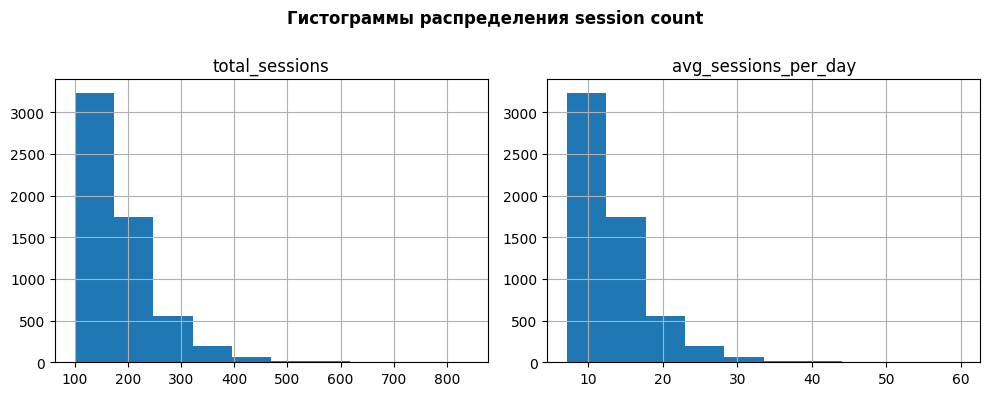

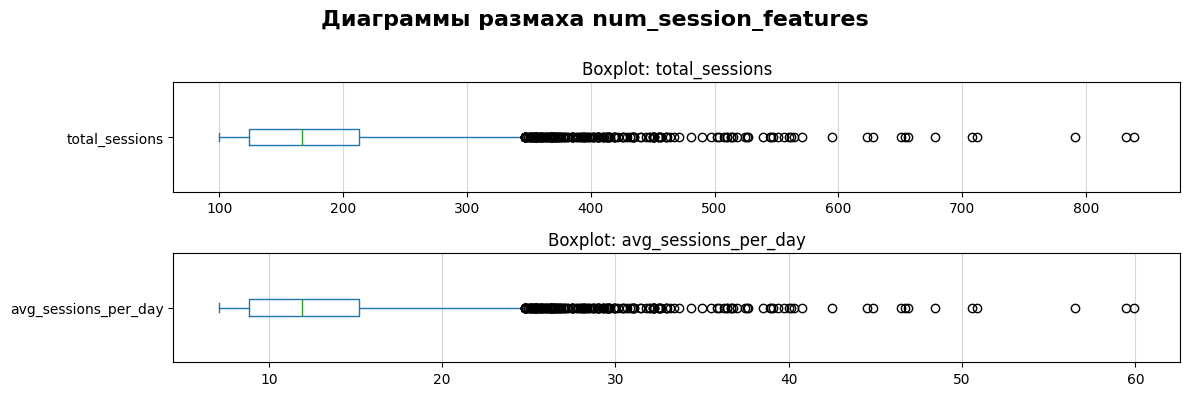

In [61]:
# Посмотрим на количественные признаки них на графиках. 
df_users_logs[num_session_features].hist(figsize=(10, 4))
plt.suptitle('Гистограммы распределения session count', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

boxplot_chart(df_users_logs, num_session_features, diagram_name='Диаграммы размаха num_session_features')

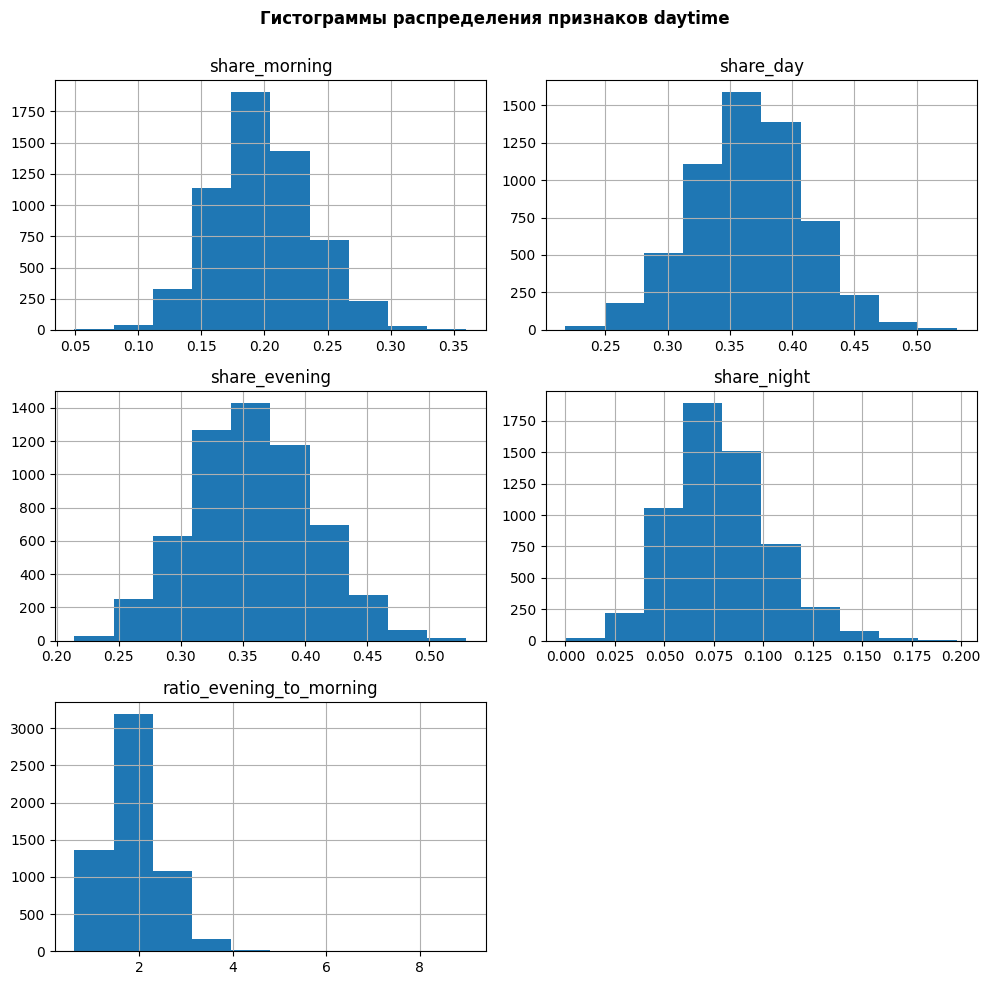

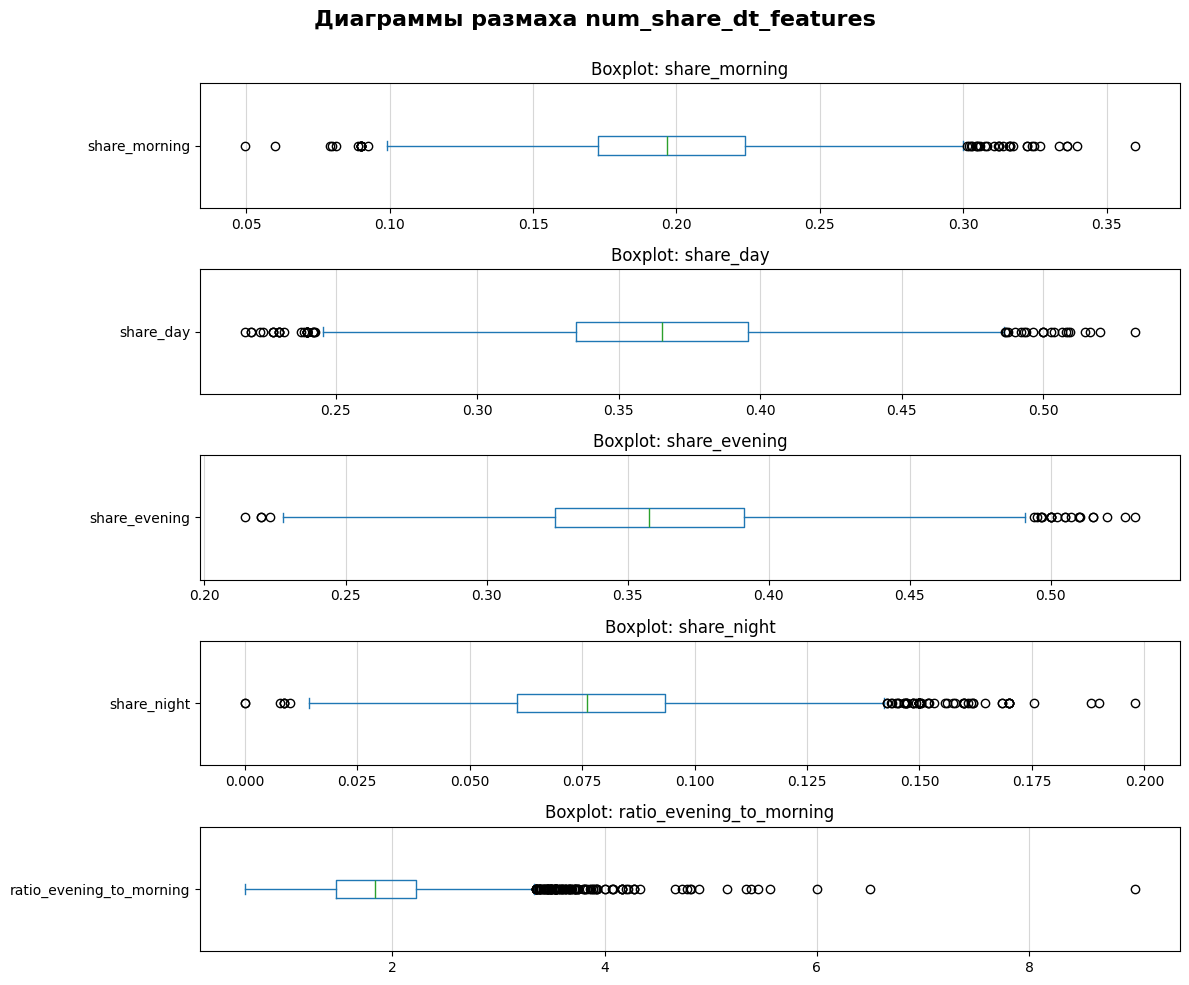

In [62]:
# Посмотрим на количественные признаки них на графиках. 
df_users_logs[num_share_dt_features].hist(figsize=(10, 10))
plt.suptitle('Гистограммы распределения признаков daytime', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

boxplot_chart(df_users_logs, num_share_dt_features, diagram_name='Диаграммы размаха num_share_dt_features')

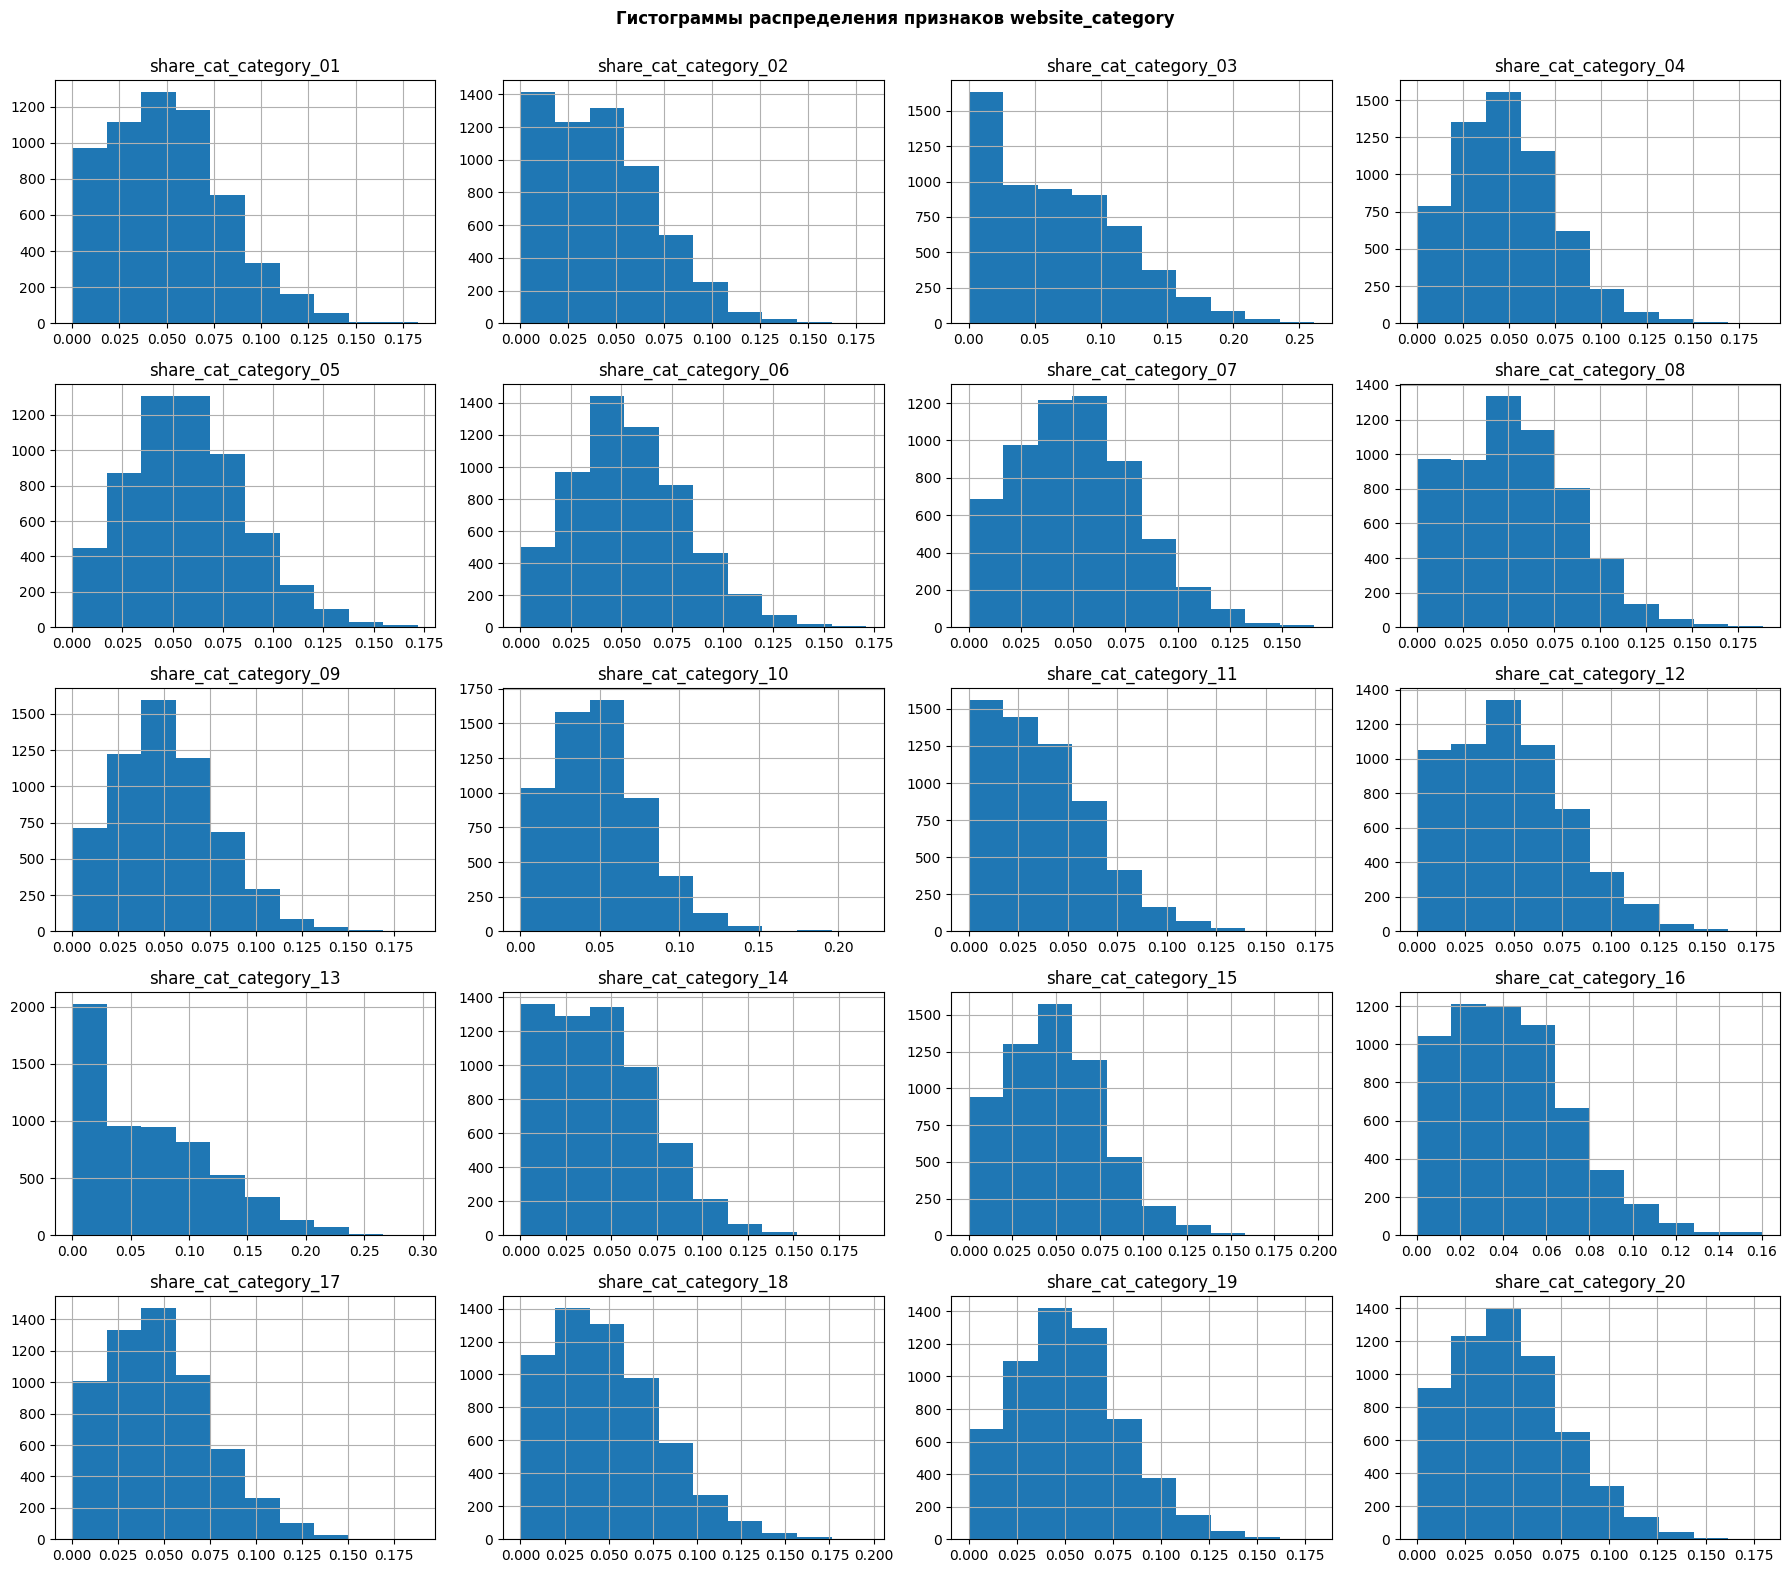

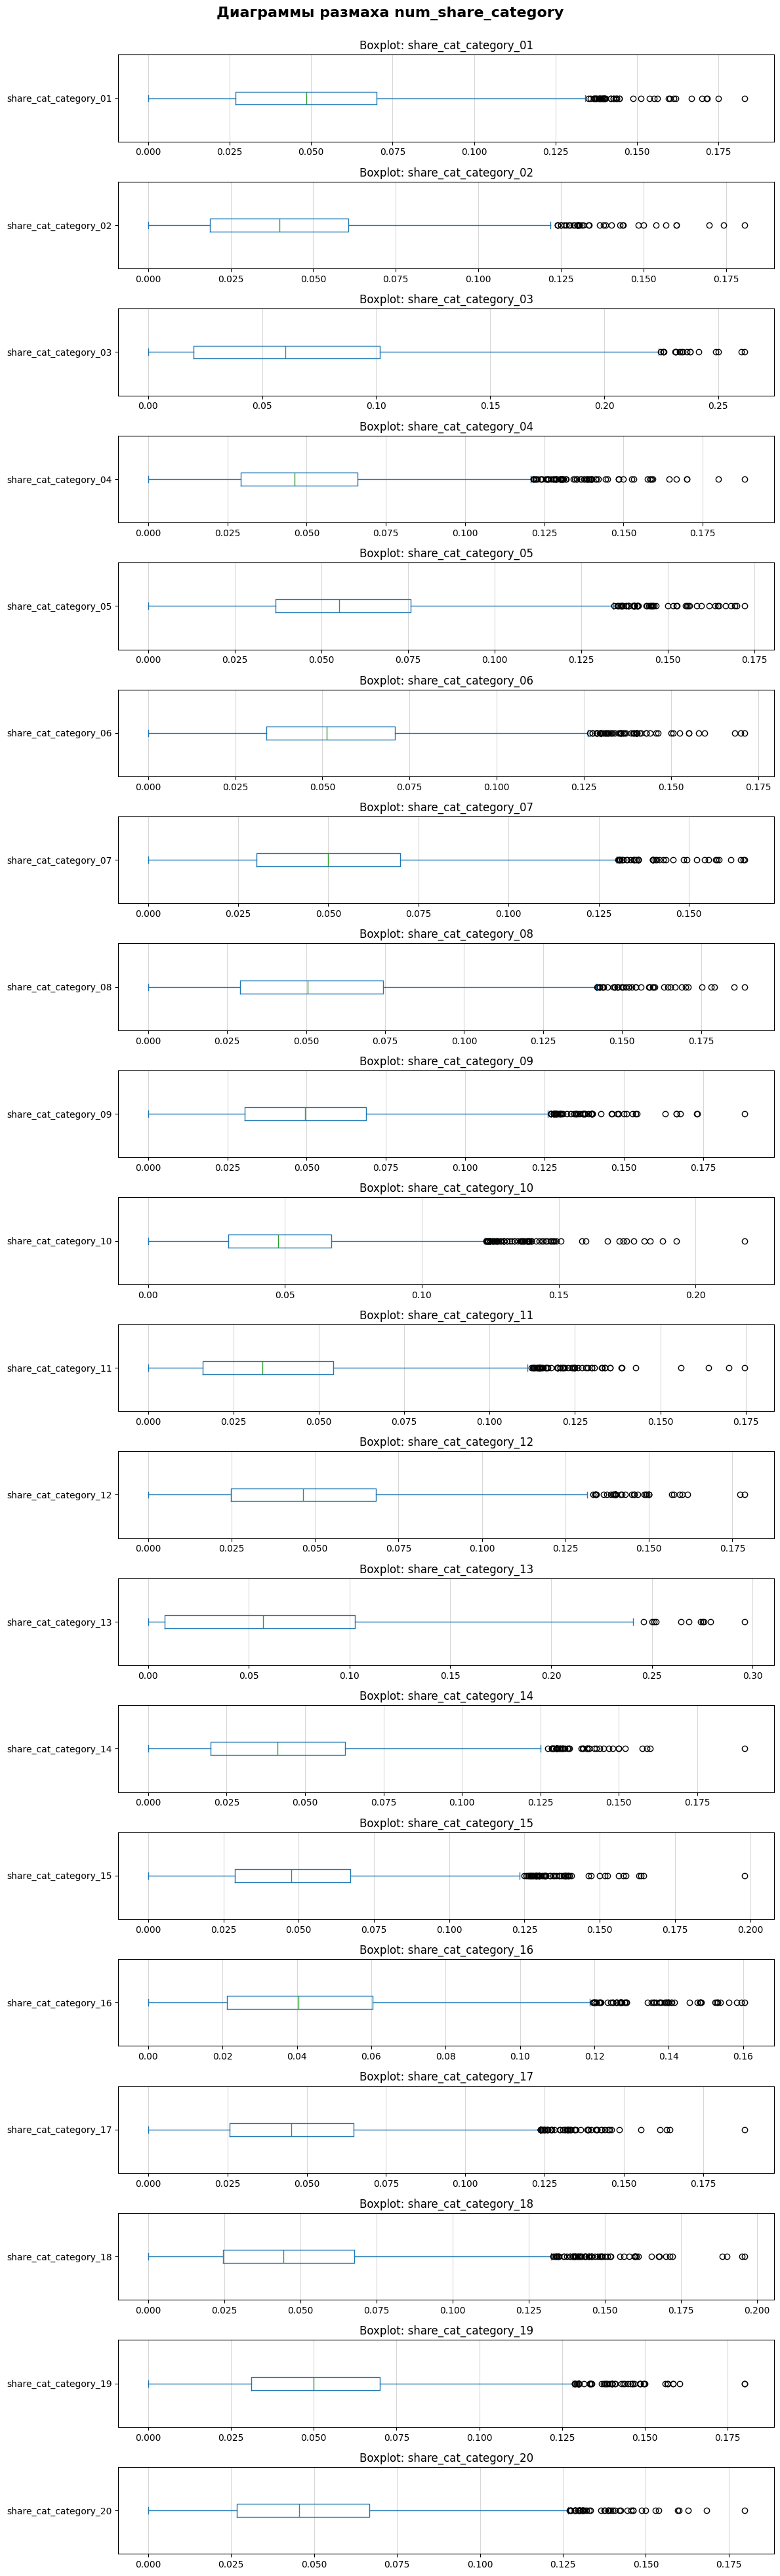

In [63]:
# Посмотрим на количественные признаки них на графиках. 
df_users_logs[num_share_category].hist(figsize=(18, 16))
plt.suptitle('Гистограммы распределения признаков website_category', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

boxplot_chart(df_users_logs, num_share_category, diagram_name='Диаграммы размаха num_share_category')

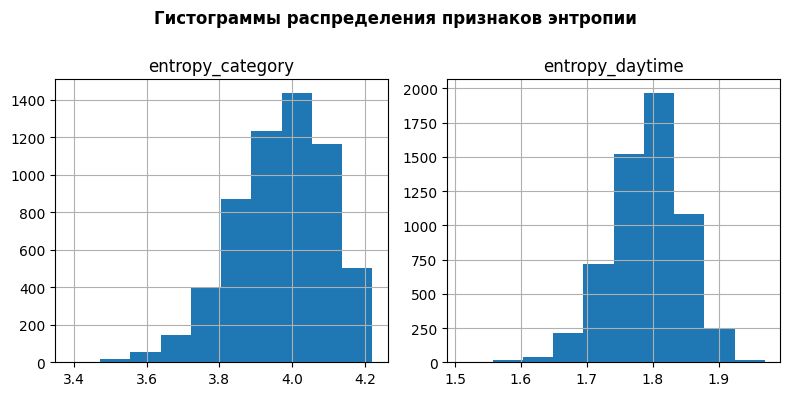

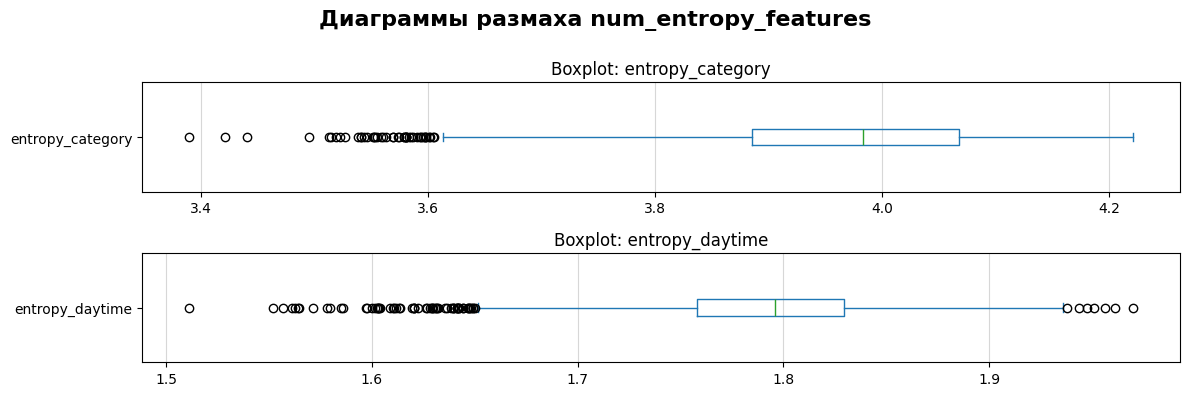

In [64]:
# Посмотрим на количественные признаки них на графиках. 
df_users_logs[num_entropy_features].hist(figsize=(8, 4))
plt.suptitle('Гистограммы распределения признаков энтропии', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

boxplot_chart(df_users_logs, num_entropy_features, diagram_name='Диаграммы размаха num_entropy_features')

In [65]:
num_log_transform_features = [
    'total_sessions',
    'avg_sessions_per_day',
    'ratio_evening_to_morning'
]

num_sqrt_transform_features = [	
    'share_cat_category_01',
    'share_cat_category_02',
    'share_cat_category_03',
    'share_cat_category_04',
    'share_cat_category_05',
    'share_cat_category_06',
    'share_cat_category_07',
    'share_cat_category_08',
    'share_cat_category_09',
    'share_cat_category_10',
    'share_cat_category_11',
    'share_cat_category_12',
    'share_cat_category_13',
    'share_cat_category_14',
    'share_cat_category_15',
    'share_cat_category_16',
    'share_cat_category_17',
    'share_cat_category_18',
    'share_cat_category_19',
    'share_cat_category_20',
    'entropy_category',
    'entropy_daytime'
]

num_no_transform_features = ['share_morning', 'share_day', 'share_evening', 'share_night']

# Проверка, что все признаки попали в списки распределения по классам трансформации
len(num_log_transform_features + num_sqrt_transform_features + num_no_transform_features) - len(numerical_features)

0

In [66]:
df_users_logs[numerical_features].corr(method='pearson').style.background_gradient(cmap='coolwarm')

,total_sessions,avg_sessions_per_day,share_day,share_evening,share_morning,share_night,share_cat_category_01,share_cat_category_02,share_cat_category_03,share_cat_category_04,share_cat_category_05,share_cat_category_06,share_cat_category_07,share_cat_category_08,share_cat_category_09,share_cat_category_10,share_cat_category_11,share_cat_category_12,share_cat_category_13,share_cat_category_14,share_cat_category_15,share_cat_category_16,share_cat_category_17,share_cat_category_18,share_cat_category_19,share_cat_category_20,entropy_category,entropy_daytime,ratio_evening_to_morning
total_sessions,1.000000,0.999992,0.006126,0.018143,-0.019115,-0.017621,-0.002094,0.007185,0.016505,-0.005269,-0.010524,-0.012816,0.001430,-0.008262,-0.027405,0.019278,-0.002685,-0.014140,-0.000862,-0.006092,0.027984,0.025226,-0.016528,-0.005124,-0.002408,0.006433,0.198429,0.057066,-0.023793
avg_sessions_per_day,0.999992,1.000000,0.005985,0.018322,-0.019149,-0.017664,-0.002108,0.007243,0.016438,-0.005146,-0.010653,-0.012796,0.001511,-0.008234,-0.027410,0.019293,-0.002676,-0.014185,-0.000882,-0.006081,0.027986,0.025219,-0.016524,-0.005107,-0.002385,0.006406,0.198520,0.057002,-0.023714
share_day,0.006126,0.005985,1.000000,-0.680057,-0.054986,-0.401825,-0.041885,-0.076453,0.037127,-0.024421,0.039371,-0.055152,-0.004270,-0.076779,0.182804,0.089094,-0.062571,-0.155121,0.211392,-0.134991,0.083371,-0.020725,0.131526,-0.104240,-0.112223,-0.107846,-0.101398,-0.427989,-0.262156
share_evening,0.018143,0.018322,-0.680057,1.000000,-0.559438,0.131542,0.019566,0.132167,-0.030458,0.037802,-0.093272,0.099784,0.035014,0.089119,-0.248222,-0.060604,0.092459,0.148220,-0.278189,0.187670,-0.057474,0.111581,-0.223793,0.087294,0.132832,0.085759,0.147156,-0.197324,0.792868
share_morning,-0.019115,-0.019149,-0.054986,-0.559438,1.000000,-0.338064,0.010945,-0.154562,0.025434,-0.003562,0.087038,-0.091301,-0.071684,-0.071730,0.234668,0.027564,-0.107293,-0.120962,0.243537,-0.178450,0.043249,-0.121335,0.226887,-0.031020,-0.109251,-0.078713,-0.134521,0.262395,-0.883847
share_night,-0.017621,-0.017664,-0.401825,0.131542,-0.338064,1.000000,0.021133,0.117555,-0.047124,-0.024613,-0.022080,0.044731,0.049393,0.075266,-0.206657,-0.086025,0.097625,0.178084,-0.213439,0.151926,-0.106010,0.004656,-0.148934,0.066257,0.111737,0.149752,0.102591,0.770448,0.277477
share_cat_category_01,-0.002094,-0.002108,-0.041885,0.019566,0.010945,0.021133,1.000000,-0.108258,0.278128,-0.272207,-0.039765,-0.212119,-0.163866,0.142390,0.042482,-0.053338,-0.031390,-0.165738,-0.459918,-0.046148,0.045082,-0.067912,-0.005059,0.220686,0.036527,-0.034741,0.041604,0.032041,-0.001215
share_cat_category_02,0.007185,0.007243,-0.076453,0.132167,-0.154562,0.117555,-0.108258,1.000000,-0.416633,-0.053252,-0.071160,0.087168,0.134904,0.127749,-0.137830,-0.067018,0.200220,0.066086,-0.143669,0.301807,-0.138411,0.137741,-0.057585,-0.113627,-0.194629,-0.094546,0.238558,0.040128,0.145837
share_cat_category_03,0.016505,0.016438,0.037127,-0.030458,0.025434,-0.047124,0.278128,-0.416633,1.000000,-0.124733,0.051267,-0.281405,-0.023203,-0.238163,-0.001236,-0.067956,-0.238045,-0.230638,-0.009946,-0.350894,0.055716,0.008732,-0.324720,-0.022007,0.213726,-0.054632,-0.381111,-0.029272,-0.033635
share_cat_category_04,-0.005269,-0.005146,-0.024421,0.037802,-0.003562,-0.024613,-0.272207,-0.053252,-0.124733,1.000000,-0.142007,0.073348,-0.199127,-0.126574,0.004418,-0.036602,-0.106259,0.017046,0.225124,-0.036403,0.039470,-0.065311,-0.088677,-0.063396,0.025583,-0.110246,0.007459,-0.027714,0.013167


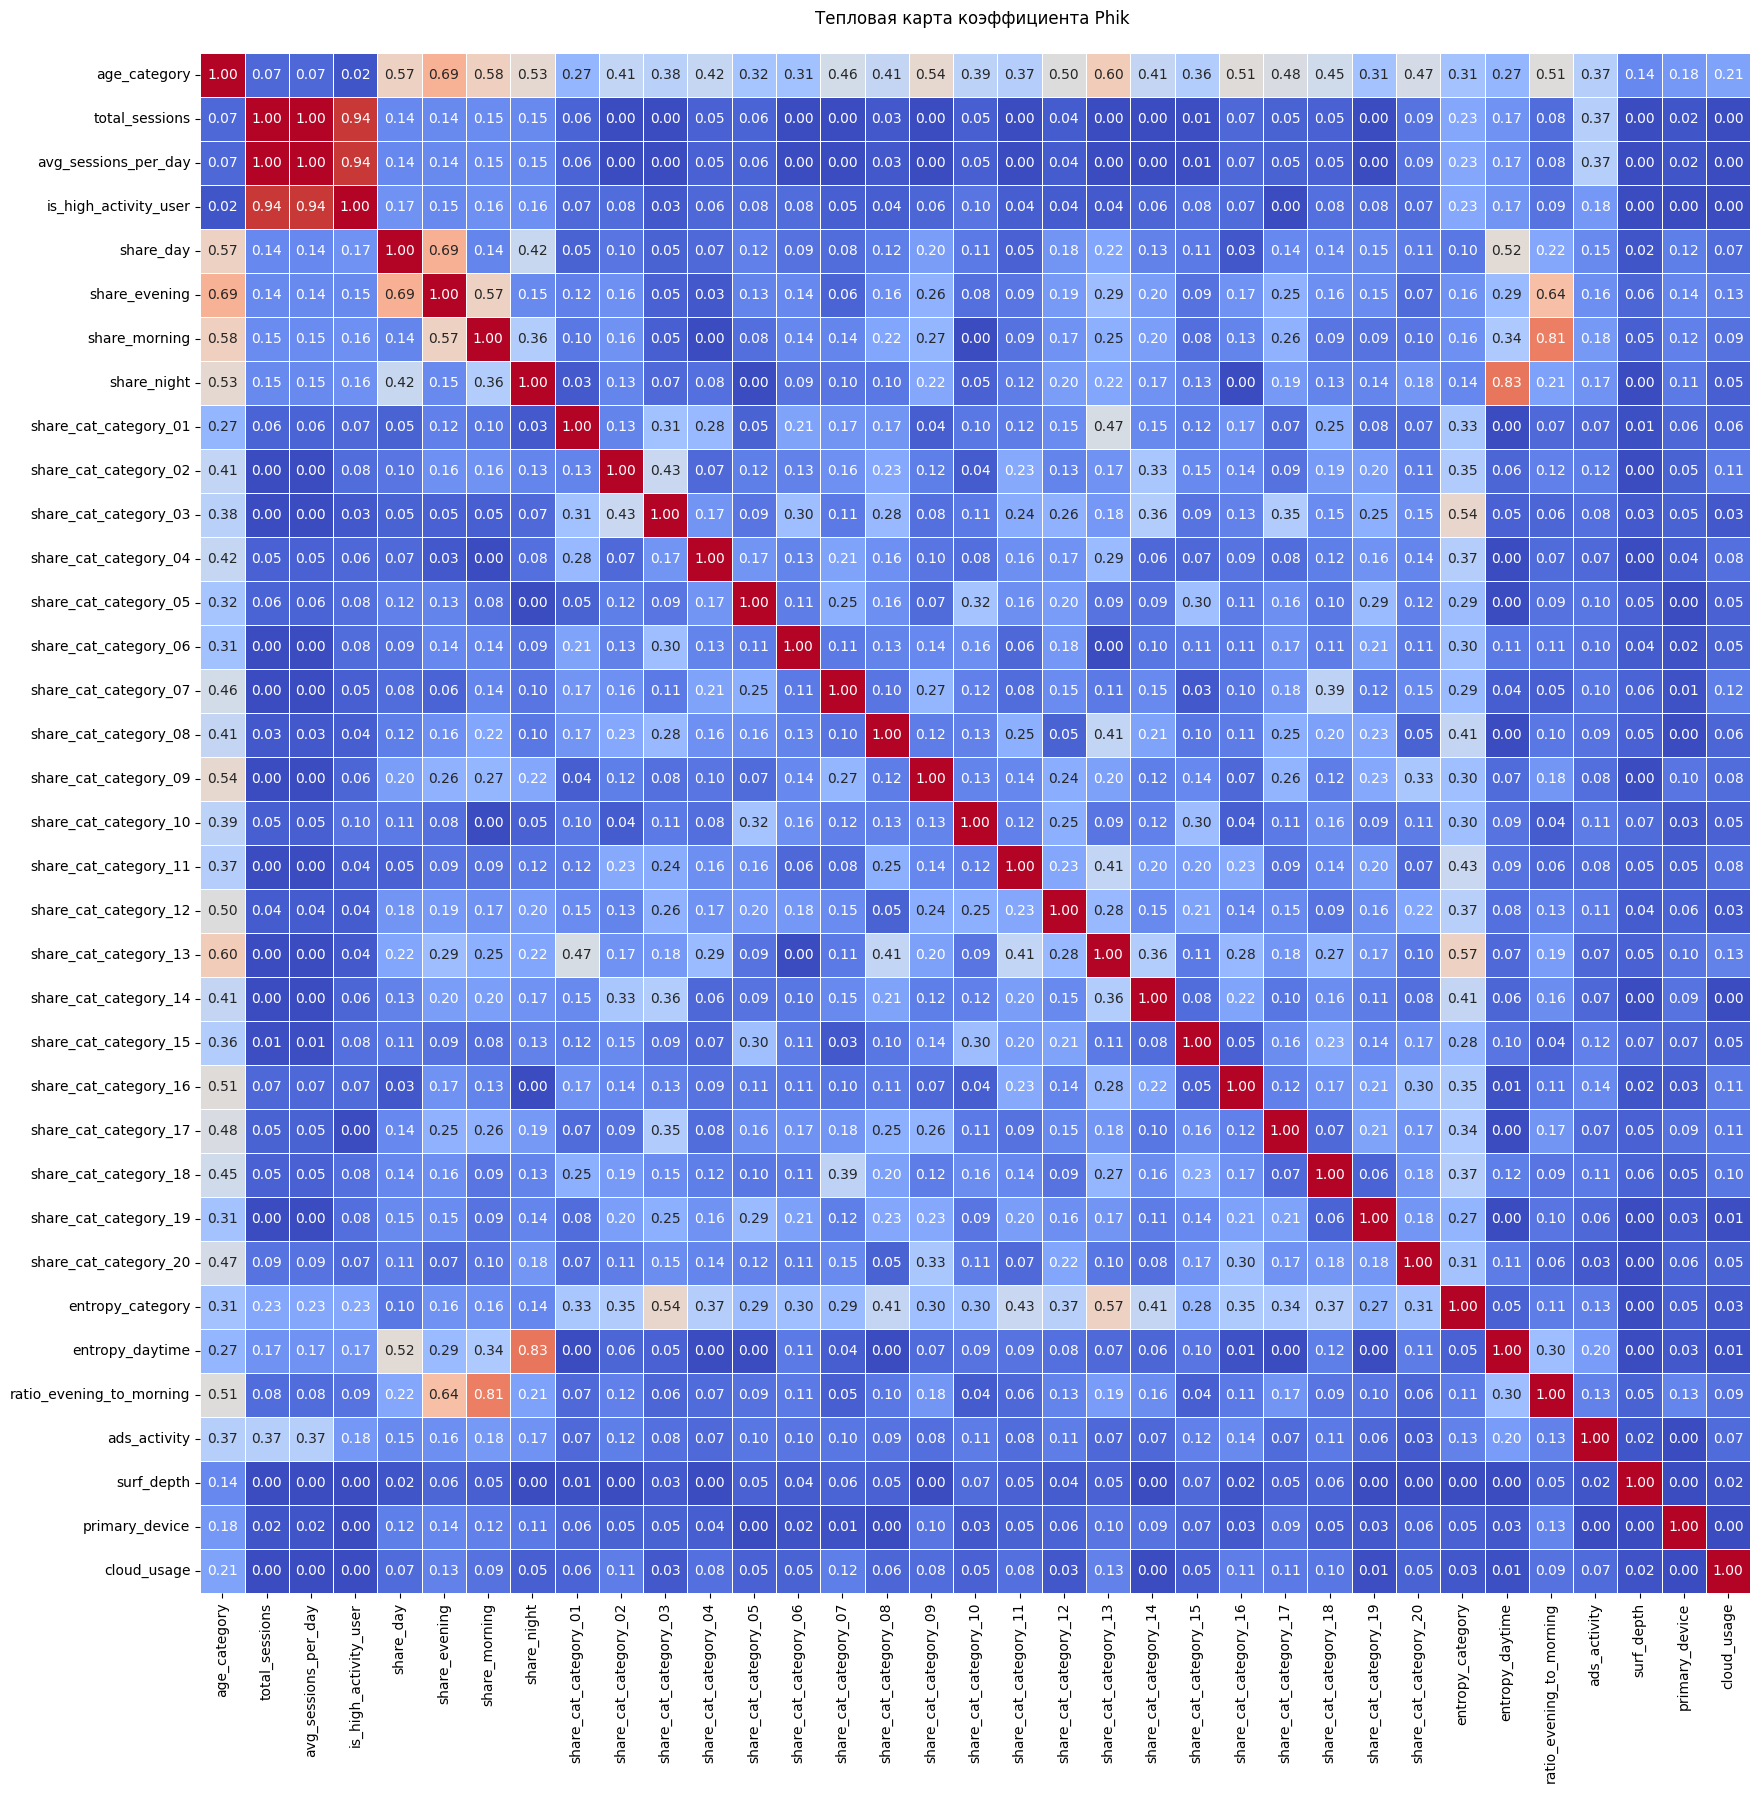

In [67]:
phik_coolwarm_matrix(df=df_users_logs, target_var='age_category', interval_cols=numerical_features, matrix_view=True, figsize=(20,20))

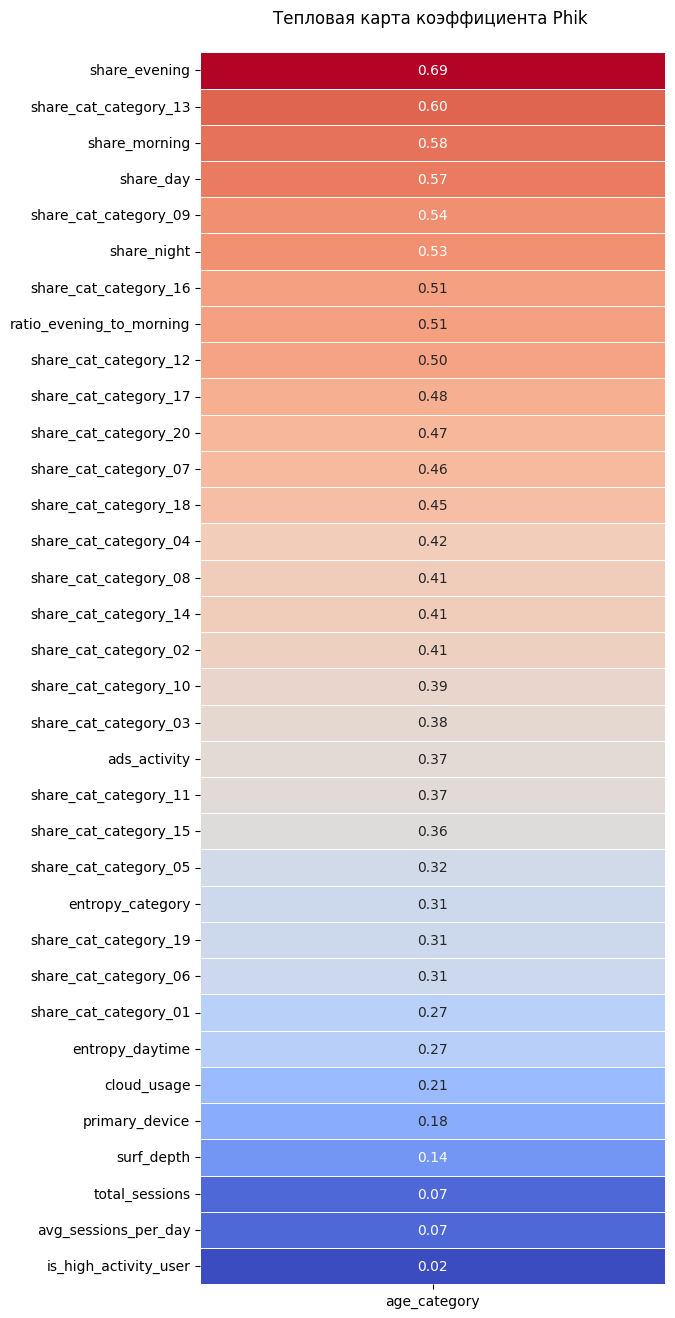

In [68]:
phik_coolwarm_matrix(df=df_users_logs, target_var='age_category', interval_cols=numerical_features, matrix_view=False, figsize=(6,16))

### Выводы по EDA
___

## 3. Предобработка данных

### 3.1 Разделение данных на выборки

In [ ]:
# =======================================================
# 1. РАЗДЕЛЯЕМ ПРИЗНАКИ И ЦЕЛЕВУЮ ПЕРЕМЕННУЮ
# =======================================================

X = df_users_logs.drop(columns=['age_category'])
y = df_users_logs['age_category']

# =======================================================
# 2. НЕЗАВИСИМОЕ РАЗБИЕНИЕ (Train, Val, Test)
# =======================================================

# Отделяем финальный Тестовый набор (20% от N_TOTAL) ---
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
) 

# =======================================================
# 3. ПРОВЕРКА РАЗМЕРОВ И ЦЕЛЕЙ
# =======================================================

print(f"Общее количество образцов: {X.shape[0]}")
print("-" * 70)
print(f'{'Набор данных':<25} {'| Размер':<8} {'| Цель':<8}')
print("-" * 70)
print(f"Тренировочный (train_val) | {len(X_train_val)}   | Обучение модели и CV-Валидация")
print(f"Тестовый (test)           | {len(X_test)}   | Финальная независимая оценка")
print("-" * 70)
print(f"Сумма: {len(X_train_val) + len(X_test)}")

###  3.2 Проверка распределения целевой переменной `age_category` в выборках

In [ ]:
plot_bar_chart(data=y_train_val, figsize=(8, 6), xlabel='Категория age_category', ylabel='Количество', title='Выборка y_train_val')

In [ ]:
plot_bar_chart(data=y_test, figsize=(8, 6), xlabel='Категория age_category', ylabel='Количество', title='Выборка y_test')

In [ ]:
# Собираем кросс-валидацию
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

### Комментарий

Выбока поделена на обучающую и тестовую в соотношении 80 к 20. Использовано стратифицированное раздение, баланс классов целевой переменной в обоих выборках сохранен.
___

### 3.3 Предобработка данных — построение пайплайнов

In [ ]:
# Пропуски в числовых признаках заполняются средним значением
num_imputer_median = SimpleImputer(strategy='median')

# Масштабирование при помощи StandardScaler
std_scaler = StandardScaler()

# Операторы заполнения пропусков категориальных признаков
cat_imputer_mode = SimpleImputer(strategy='most_frequent')

# Операторы кодирования категориальных переменных
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Трансформер log и sqrt
log_sqrt_transformer = LogSqrtTransformer(log_cols=num_log_transform_features, sqrt_cols=num_sqrt_transform_features)

# Создаем пайплайны
num_log_sqrt_column_pipe = Pipeline(
    steps=[
        ('log_sqrt', log_sqrt_transformer),   # сначала преобразуем и переименуем
        ('simple_imputer', num_imputer_median),
        ('std_scaler', std_scaler)
    ]
)

# Создаем пайплайны
num_no_trans_column_pipe = Pipeline(
    steps=[
        ('simple_imputer', num_imputer_median),
        ('std_scaler', std_scaler)
    ]
)

cat_column_pipe = Pipeline(
    steps=[
        ('imputer', cat_imputer_mode),
        ('ohe', one_hot_encoder)
    ]
)

# Строим трансформер колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('numls', num_log_sqrt_column_pipe, num_log_transform_features+num_sqrt_transform_features),
        ('numno', num_no_trans_column_pipe, num_no_transform_features),
        ('cat', cat_column_pipe, categorical_features)
    ],
    remainder='drop'
)

preprocessor

In [ ]:
# Проверим работу preprocessor

X_transformed = preprocessor.fit_transform(X_train_val, y_train_val)

feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

X_transformed_df.head()

## Обучение и оценка базовой модели

## Создание и отбор признаков

## Подбор гиперпараметров моделей

## Подготовка артефактов модели для внедрения

## Выводы о результатах работы